In [1]:
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, root_mean_squared_error, r2_score

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Task 1 — Eksplorasi Data Awal

In [2]:
data = fetch_california_housing(as_frame=True)
df = data.frame
df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   MedInc       20640 non-null  float64
 1   HouseAge     20640 non-null  float64
 2   AveRooms     20640 non-null  float64
 3   AveBedrms    20640 non-null  float64
 4   Population   20640 non-null  float64
 5   AveOccup     20640 non-null  float64
 6   Latitude     20640 non-null  float64
 7   Longitude    20640 non-null  float64
 8   MedHouseVal  20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB


In [4]:
df.isna().sum()

MedInc         0
HouseAge       0
AveRooms       0
AveBedrms      0
Population     0
AveOccup       0
Latitude       0
Longitude      0
MedHouseVal    0
dtype: int64

In [5]:
df.describe()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704,2.068558
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532,1.153956
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000,1.196000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,1.797000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,2.647250
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,5.000010


Text(0, 0.5, 'Median House Val')

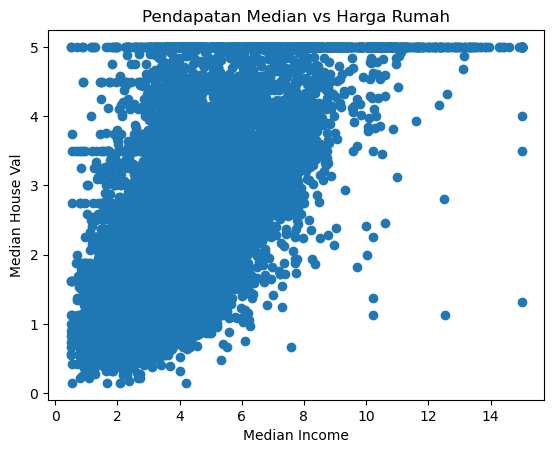

In [9]:
plt.scatter(df['MedInc'], df['MedHouseVal'])
plt.title('Pendapatan Median vs Harga Rumah')
plt.xlabel('Median Income')
plt.ylabel('Median House Val')

Variable Median Income dan Median house Val memiliki hubungan yang positif linear. Namun, ketika median income > 8, hubungan linear positif dengan median house val berkurang.

# Task 2 — Simple Linear Regression

In [19]:
X = df[['MedInc']]
y = df[['MedHouseVal']]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Train length: {len(X_train)}")
print(f"Test length: {len(X_test)}")

Train length: 16512
Test length: 4128


In [20]:
lr = LinearRegression()
reg = lr.fit(X_train, y_train)

In [6]:
print(f"Koefisien: {reg.coef_}")
print(f"Intercept: {reg.intercept_}")

Koefisien: [[0.41933849]]
Intercept: [0.44459729]


In [ ]:
y_pred = reg.predict(X_test)
y_pred

array([[1.14958917],
       [1.50606882],
       [1.90393718],
       ...,
       [4.31500772],
       [1.612455  ],
       [1.93412956]], shape=(4128, 1))

In [8]:
print(f"MAE: {mean_absolute_error(y_test, y_pred)}")
print(f"MSE: {mean_squared_error(y_test, y_pred)}")
print(f"Root MSE: {root_mean_squared_error(y_test, y_pred)}")
print(f"R2: {r2_score(y_test, y_pred)}")

MAE: 0.629908653009376
MSE: 0.7091157771765548
Root MSE: 0.8420901241414454
R2: 0.45885918903846656


In [28]:
y_pred = reg.predict(X_train)
print(f"MAE: {mean_absolute_error(y_train, y_pred)}")
print(f"MSE: {mean_squared_error(y_train, y_pred)}")
print(f"Root MSE: {root_mean_squared_error(y_train, y_pred)}")
print(f"R2: {r2_score(y_train, y_pred)}")

MAE: 0.6249507655668727
MSE: 0.6991447170182823
Root MSE: 0.8361487409655547
R2: 0.4769927345820524


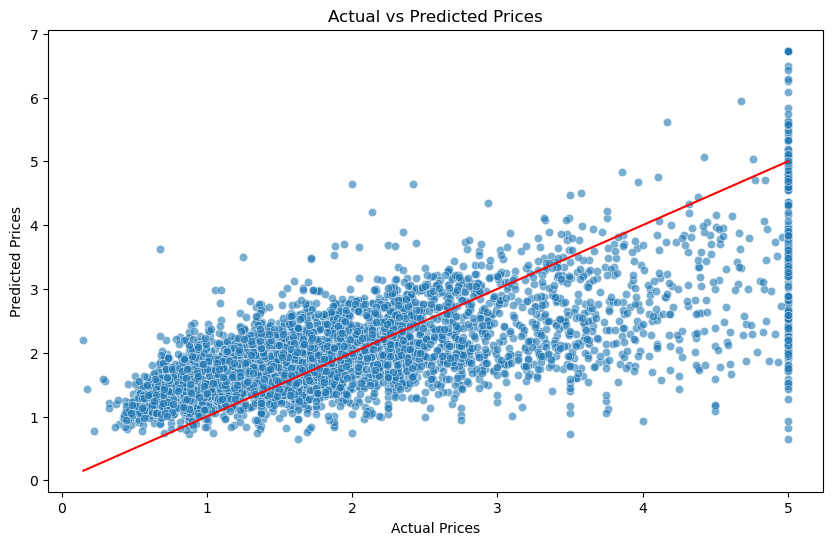

In [ ]:
plt.figure(figsize=(10,6))
sns.scatterplot(x=y_test.iloc[:,0], y=y_pred.reshape(1,-1)[0], alpha=0.6)
sns.lineplot(x=[y_test.iloc[:,0].min(), y_test.iloc[:,0].max()], y=[y_test.iloc[:,0].min(), y_test.iloc[:,0].max()], color='red')
plt.title('Actual vs Predicted Prices')
plt.xlabel('Actual Prices')
plt.ylabel('Predicted Prices')
plt.show()


# Task 3 — Multiple Linear Regression


In [10]:
X = df.drop('MedHouseVal', axis=1)
y = df['MedHouseVal']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)
model = LinearRegression()

In [11]:
reg = model.fit(X_train, y_train)

In [52]:
y_pred = reg.predict(X_test)
print(f"MAE: {mean_absolute_error(y_pred, y_test)}")
print(f"MSE: {mean_squared_error(y_pred, y_test)}")
print(f"Root MSE: {root_mean_squared_error(y_pred, y_test)}")
print(f"R2: {r2_score(y_pred, y_test)}")

MAE: 0.5332001304956555
MSE: 0.5558915986952442
Root MSE: 0.7455813830127763
R2: 0.3376701658930962


In [54]:
y_pred = reg.predict(X_train)
print(f"MAE: {mean_absolute_error(y_pred, y_train)}")
print(f"MSE: {mean_squared_error(y_pred, y_train)}")
print(f"Root MSE: {root_mean_squared_error(y_pred, y_train)}")
print(f"R2: {r2_score(y_pred, y_train)}")

MAE: 0.5286283596581923
MSE: 0.5179331255246699
Root MSE: 0.7196757085831575
R2: 0.3674833809075225


| R2-Score | Simple | Multi |
|----------|--------|-------|
| Training | 0.476  | 0.367 |
| Testing  | 0.458  | 0.337 |

Simple dan multi linear regression menunjukkan hasil yang cukup baik. dimana kedua model ada di kategori good fit. Hal ini ditunjukkan oleh pola yang wajar, dimana model dapat belajar dari data training, dan tidak memiliki selisih performah yang jauh pada data testing.

# Task 4 — Interpretasi dan Diagnosa Model

Dari hasil yang didapatkan, model termasuk kedalam kategori goodfit. MOdel dapat belajar dari data training. Meskipun r2 score lebih besar di pada data training, hal ini wajar terjadi, karena memang seharusnya model punya performa lebih baik di data training. Hal ini belum dikategorikan overfitting karena selisih r2 score data train dan testing yang tidak terlalu signifikan.

In [18]:
print(f"MAPE: {np.mean(np.abs((y_test.to_numpy().reshape(-1,1) - y_pred.reshape(-1,1)) / y_test.to_numpy().reshape(-1,1))) * 100} %")

MAPE: 39.05583956532854 %


MAPE adalah nilai error dalam satuan persen. Jika MAPE adalah 39%, berarti model memiliik error sebsesar 39%. JIka model ini digunakan dalam membantu keputusan dalam pembelian rumah, maka model ini masih perlu peningkatan dikarenakan memiliki margin of error yang tergolong tinggi.

Untuk perbaikan, dapat dilakukan dengan menambahkan fitur yang kiranya memungkinkan yang berpangaruh terhadap harga rumah, seperti data luas area rumah.